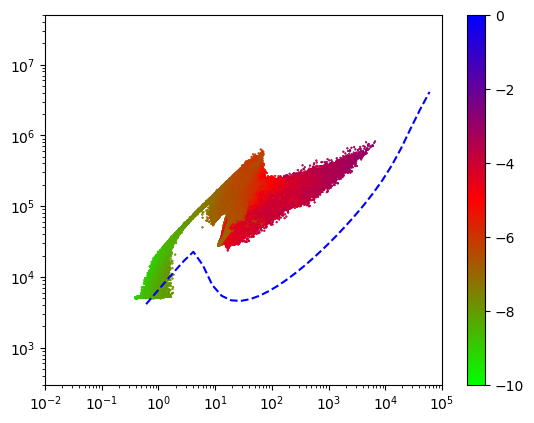

In [4]:
# coding: UTF-8
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import h5py
import csv
import math
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.animation as animation
from matplotlib.animation import ArtistAnimation
from sympy import *
from sympy.codegen.cfunctions import log10

#dir = '/Users/maedarn/Dropbox/analysis/low_metal/lmt_m4_v100_d100_old/'
dir = '/Users/maedarn/Dropbox/analysis/low_metal/lmt_m4/'
#dir1 = '/Users/maedarn/Dropbox/code/code/Cooling_Kim/'
dir1 = '/Users/maedarn/Dropbox/analysis/cooling/Kim/'
dirD = '/Users/maedarn/Desktop/'
im=128
jm=128
km=128
num=18
nstep = 20
#itime = 1
#ftime = 104
itime = 130
ftime = 130
timejump=1
#folder1="Phiwv"  #+ str(np.int(sample_frequency)) 
#older2="Phiexa"  #+ str(np.int(sample_frequency)) 

ci=51
cj=29+2+6
cf90 = open(dir1+'Thermal_bialym_Z10m4_md_mid.dat', 'rb')
#cf90 = open(dir1+'Thermal_intm2_md_mid.dat', 'rb')
cary = np.fromfile(cf90, np.float64, count=ci*cj)
cuvhpy = cary.reshape(cj, ci, order='F')
cT         =cuvhpy[1,:]
cndtotl =cuvhpy[12,:]

ci=31
cj=29
#df90 = open(dir1+'Thermal_bialym_Z10m2_md_mid.dat', 'rb')
df90 = open(dir1+'Thermal_intm2_l_mid.dat', 'rb')
dary = np.fromfile(df90, np.float64, count=ci*cj)
duvhpy = dary.reshape(cj, ci, order='F')
dT         =duvhpy[1,:]
dndtotl =duvhpy[12,:]
dG0 =duvhpy[0,:]/1.27

#ef90 = open(dir1+'Thermal_bialym_Z10m2_md_mid.dat', 'rb')
ef90 = open(dir1+'Thermal_intm2_md_mid.dat', 'rb')
eary = np.fromfile(ef90, np.float64, count=ci*cj)
euvhpy  =eary.reshape(cj, ci, order='F')
eT      =euvhpy[1,:]
endtotl =euvhpy[12,:]

#fig, ax = plt.subplots()
fig = plt.figure()
#ax = fig.add_subplot(111)
#ax1 = fig.add_subplot(111)
ax = fig.add_subplot(1,1,1)
for i in range(itime,ftime +1,timejump): #最後は含まない
#h5file1 = h5py.File(dir1+'NAllHDF'+"%03.f"%(i)+'.h5',"r")
    with h5py.File(dir+'zHDFALL'+"%03.f"%(i)+'.h5',"r")as f:
        RHO  = f["RHO/RHO"]
        Vx  = f["V/VX"]
        Vy  = f["V/VY"]
        Vz  = f["V/VZ"]
        P = f["P/P"]
        #RHO_1D = np.reshape(G0, (im*jm*km))
        #P_1D = np.reshape(P, (im*jm*km))
        #x1=G0_1D/1.27
        #y1=slice5*116.0
        #y1=P_1D*116.0*1.27
        

        nH2 = f["RHO-h2/RHO-h2"]

        RHO_1D = np.reshape(RHO, (im*jm*km))
        P_1D = np.reshape(P, (im*jm*km))
        nH2_1D= np.reshape(nH2, (im*jm*km))
        nH2_1Df = np.log10(nH2_1D*1.27/RHO_1D)
        x1=RHO_1D/1.27
        #y1=slice5*116.0
        y1=P_1D*116.0*1.27
        #Rho=np.reshape(RHO, im,jm,km)
    
    #mvx=np.mean(RHO)
    #shockedrho = np.where(RHO > 10.0, 1, 0)
    #shockedvx = np.where(abs(Vx) < 40.0, 1, 0)
    #shock = shockedrho + shockedvx
    #shocked_Region = np.where(shock >= 1, 1, 0)
    
    #Vx_sh=Vx * shocked_Region 
    x = np.arange(1, 6)
    #x10=10.0**x
    #y = 50*x + 1
    
    
    #ax.set_xlabel('n')  # x軸ラベル
    #ax.set_ylabel('p/k_{B}')  # y軸ラベル
    #ax.set_title(r'$\sin(x)$ and $\cos(x)$') # グラフタイトル
    # ax.set_aspect('equal') # スケールを揃える
    #ax.grid()            # 罫線
    #plt.yscale('log')
    #plt.xscale('log')
    #plt.plot(10.0**x, 50*10.0**x*0.1,color='blue')
    #matplotlib.pyplot.scatter
    #plt.plot(cndtotl, cT*cndtotl*1000.0 ,color='blue',linestyle='solid')
    plt.plot(dndtotl, dT*dndtotl*1000.0 ,color='blue',linestyle='dashed')
    #plt.plot(endtotl, eT*dndtotl*1000.0 ,color='blue',linestyle='dashdot')
    #plt.scatter(x1, y1, s=0.2,color='red')
    plt.scatter(x1, y1, c=nH2_1Df, vmin=-10, vmax=0, cmap='brg_r', s=0.2)# norm=LogNorm())#, s=20)#, c=None, marker='o', cmap=None, norm=None,vmin=None, vmax=None, alpha=None, linewidths=None,verts=None, edgecolors=None, hold=None, data=None,**kwargs)
    mappable = plt.scatter(x1, y1, c=nH2_1Df, vmin=-10, vmax=0, cmap='brg_r', s=0.2)
    fig.colorbar(mappable)
    ax.set_yscale('log')  # y軸をlogスケールで描く
    ax.set_xscale('log')  # x軸をlogスケールで描く
    ax.set_xlim([0.01, 100000]) # x方向の描画範囲を指定
    ax.set_ylim([300, 50000000])    # y方向の描画範囲を指定
    #p = plt.plot(data01,data02, "black", linestyle='dashed') # normal way
    #ax.plot(t, y1, color=c1, label=l1)
    #ax.plot(t, y2, color=c2, label=l2)
    #ax.plot(t, y3, color=c3, label=l3)
    #ax.plot(t, y4, color=c4, label=l4)
    #ax.legend(loc=0)    # 凡例
    #fig.tight_layout()  # レイアウトの設定
    plt.savefig(dirD+'hoge.png',transparent=True) # 画像の保存
    plt.show()
                    
                    
    #plt.savefig("foo.png")
    
    
   
      


[6.05747367e-01 8.89115541e-01 1.30504314e+00 1.91554137e+00
 2.81163022e+00 4.12690877e+00 6.05747368e+00 8.89115541e+00
 1.30504314e+01 1.91554137e+01 2.81163021e+01 4.12690877e+01
 6.05747367e+01 8.89115541e+01 1.30504314e+02 1.91554136e+02
 2.81163021e+02 4.12690877e+02 6.05747367e+02 8.89115541e+02
 1.30504314e+03 1.91554136e+03 2.81163021e+03 4.12690877e+03
 6.05747367e+03 8.89115541e+03 1.30504314e+04 1.91554136e+04
 2.81163021e+04 4.12690877e+04 6.05747367e+04]


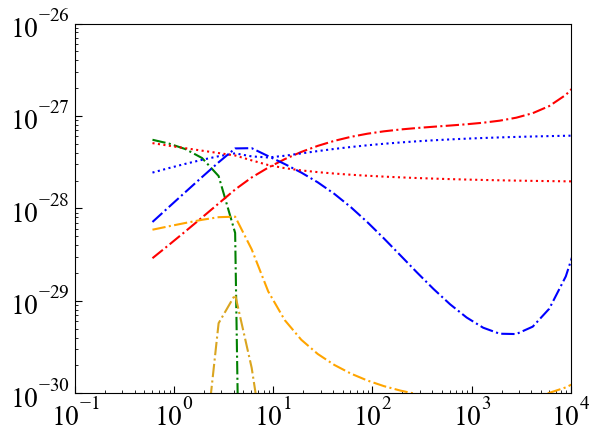

In [51]:
i=31
nnnj=cj=29+2+6

f90 = open(dir1+'Thermal_intm2_md_mid.dat', 'rb')

ary = np.fromfile(f90, np.float64, count=i*nnnj)
uvhpy = ary.reshape(nnnj, i, order='F')



T         =uvhpy[1,:]
Rho    =uvhpy[0,:]
ndpl    =uvhpy[2,:]
ndHl    =uvhpy[3,:]
ndH2l  =uvhpy[4,:]
ndHml =uvhpy[5,:]
ndHel  =uvhpy[6,:]
ndHepl=uvhpy[7,:]
ndCl    =uvhpy[8,:]
ndCpl  =uvhpy[9,:]
ndCOl =uvhpy[10,:]
ndel    =uvhpy[11,:]
ndtotl =uvhpy[12,:]
Lamll =uvhpy[13,:]
Lamcl =uvhpy[14,:]
Lamol =uvhpy[15,:]
Lamdl =uvhpy[16,:]
LCOrl =uvhpy[17,:]
LCOHl =uvhpy[18,:]
LCOH2l =uvhpy[19,:]
LamH2l =uvhpy[20,:]
Lffl =uvhpy[21,:]
Lrrl =uvhpy[22,:]
LCIEl =uvhpy[23,:]
LCIEHel =uvhpy[24,:]
Gampel =uvhpy[25,:]
Gamcrl   =uvhpy[26,:]
Gampdl =uvhpy[27,:]
Lneb =uvhpy[28,:]
Gampdl1 =uvhpy[29,:]
Gampdl2 =uvhpy[30,:]
Lamdg =uvhpy[31,:]
LH2a =uvhpy[32,:]
LH2b =uvhpy[33,:]
LH2c =uvhpy[34,:]
LH2d =uvhpy[35,:]
LH2e =uvhpy[36,:]



fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

#plt.xlim(0.1, 100)a
#plt.xlim(0.000001, 1.0)
#plt.ylim(10**(-28), 10**(-25))
#plt.ylim(0.001, 0.1)
#plt.ylim(300, 50000000.0)
#plt.ylim(100, 10000000.0)
plt.ylim(1.e-30,1.e-26)
plt.xlim(0.1, 10000)
ax.set_yscale('log')
ax.set_xscale('log')

print(ndtotl)

#plt.plot(ndtotl, ndtotl*T*8.63359*90.8 ,color='green',linestyle='solid')
#plt.plot(ndtotl, ndtotl*T*1000.0 ,color='purple',linestyle='dashdot')
#plt.plot(ndtotl1, ndtotl1*T1*1000.0 ,color='blue',linestyle='dashdot')
#plt.plot(ndtotl2, ndtotl2*T2*1000.0 ,color='red',linestyle='dashdot')
#plt.plot(ndtotl3, ndtotl3*T3*1000.0 ,color='orange',linestyle='dashdot')
#plt.plot(ndtotl, ndtotl*T ,color='green',linestyle='solid')
#plt.plot(nndtotl, nndtotl*nT*1000.0 ,color='green',linestyle='solid')
#plt.plot(ondtotl, ondtotl*oT*1000.0 ,color='green',linestyle='solid')
#plt.plot(Rho/1.27, Rho/1.27*T*1000.0 ,color='green',linestyle='solid')
#plt.plot(nRho/1.27, nRho/1.27*nT*1000.0 ,color='green',linestyle='solid')
#plt.plot(oRho/1.27, oRho/1.27*oT*1000.0 ,color='green',linestyle='solid')
#plt.plot(Rho/1.27, T*Rho/1.27*1000.0 ,color='red',linestyle='dashed')
#plt.plot(ndtotl, T*1000.0 ,color='red')
#plt.plot(Rho/1.27, T*Rho/1.27*1000.0 ,color='red')

#plt.plot(Rho/1.27, Lamll/1.9733e27/(Rho/1.27) ,color='red')
#plt.plot(Rho/1.27, Lamcl/1.9733e27/(Rho/1.27),color='green')
#plt.plot(Rho/1.27, Lamol/1.9733e27/(Rho/1.27),color='blue')
#plt.plot(Rho/1.27, Lamdl/1.9733e27 /(Rho/1.27),color='purple')
#plt.plot(Rho/1.27, Gampel /1.9733e27 /(Rho/1.27),color='yellow')
#plt.plot(Rho/1.27, Gamcrl /1.9733e27/(Rho/1.27),color='gray')
#plt.plot(Rho/1.27, Gampdl /1.9733e27 /(Rho/1.27),color='magenta')


plt.plot(ndtotl, Lamll/1.9733e27/(ndtotl) ,color='green',linestyle='dashdot')
plt.plot(ndtotl, Lamcl/1.9733e27/(ndtotl),color='red',linestyle='dashdot')
plt.plot(ndtotl, Lamol/1.9733e27/(ndtotl),color='blue',linestyle='dashdot')
plt.plot(ndtotl, Lamdl/1.9733e27 /(ndtotl),color='orange',linestyle='dashdot')
plt.plot(ndtotl, Gampel /1.9733e27 /(ndtotl),color='blue',linestyle='dotted')
plt.plot(ndtotl, Gamcrl /1.9733e27/(ndtotl),color='red',linestyle='dotted')
#plt.plot(ndtotl, Gampdl /1.9733e27 /(ndtotl),color='green',linestyle='dotted')
#plt.plot(ndtotl, Gampdl1 /1.9733e27 /(ndtotl),color='purple',linestyle='dotted')
#plt.plot(ndtotl, Gampdl2 /1.9733e27 /(ndtotl),color='orange',linestyle='dotted')
#plt.plot(ndtotl, (Lffl+Lrrl) /1.9733e27 /(ndtotl),color='black',linestyle='dashdot')
#plt.plot(ndtotl, (LCIEl+LCIEHel )/1.9733e27 /(ndtotl),color='brown',linestyle='dashdot')
#plt.plot(ndtotl, Lneb/1.9733e27 /(ndtotl),color='cyan',linestyle='dashdot')
plt.plot(ndtotl, LamH2l/1.9733e27 /(ndtotl),color='goldenrod',linestyle='dashdot')
plt.plot(ndtotl, (LCOH2l+LCOHl+LCOrl)/1.9733e27 /(ndtotl),color='indigo',linestyle='dashdot')
#plt.plot(ndtotl, Lamdg/1.9733e27 /(ndtotl),color='magenta',linestyle='dashdot')
#plt.plot(ndtotl, LH2a /1.9733e27/(ndtotl),color='coral',linestyle='dashdot')
#plt.plot(ndtotl, LH2b/1.9733e27 /(ndtotl),color='coral',linestyle='dashdot')
#plt.plot(ndtotl, LH2c/1.9733e27 /(ndtotl),color='coral',linestyle='dashdot')
#plt.plot(ndtotl, LH2d/1.9733e27 /(ndtotl),color='coral',linestyle='dashdot')
#plt.plot(ndtotl, LH2e/1.9733e27 /(ndtotl),color='coral',linestyle='dashdot')


plt.show()

pp = PdfPages('/Users/maedarn/Desktop/Cooling_Code_Hot.pdf')
pp.savefig(fig,transparent=True)
pp.close()



[  3.57142857   5.95750192   9.93771215  16.57710298  27.65227438
  46.12677375  76.94409607 128.35048799 214.10151797 357.14285714] 86800.0 [  244094.48818898   407174.1468756    679207.41313717  1132986.25072438
  1889934.97347362  3152601.54452452  5258856.32999908  8772301.0691294
 14633080.12589541 24409448.81889763]
[939.57257866 563.25896294 337.66487713 202.42477573 121.35046492
  72.74769249  43.61109589  26.14416513  15.67301523   9.39572579] [42.42640687 32.84922603 25.43396272 19.69259364 15.24726007 11.80539973
  9.14049227  7.07715121  5.47958116  4.24264069] [14.8492424   8.90188695  5.33654103  3.1991723   1.91785341  1.14972291
  0.68924078  0.41318899  0.24770029  0.14849242]
38.18376618407357 14.849242404917497


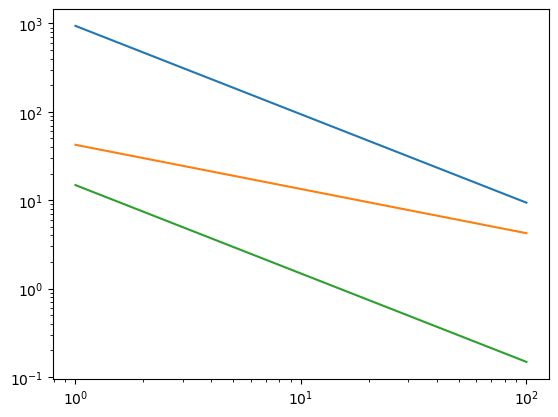

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#---parameters---
M=5.0
cs0=10.0
v0=M*cs0 #100.0
T0=10000.0
gmm=5.0/3.0
mu=1.27
Z=0.0001
Tline=100.0
delta=0.2
B0=1.0
#---parameters---

#n0 = 1.0#np.linspace( -4, 3, 8)
n0log = np.linspace( 0.0, 2.0,10)
n0=10.0**(n0log)
n1 = n0*(gmm+1.0)*M*M/((gmm-1.0)*M*M+2.0)
T1 = T0*(2.0*gmm*M*M-(gmm-1.0))*((gmm-1.0)*M*M+2.0)/((gmm+1.0)**2*M*M)
p1=n1*T1/mu
print(n1,T1,p1)

tcool = 0.4*(Z/1.0)**(-1.0)*(n1/1.0)**(-3.0/2.0)*(p1/1.e5)**(0.5)*np.exp(0.01*(Tline/100.0)*(n1/1.0)*(p1/1.e5)**(-1.0))
tg=30.0*(delta/0.2)**(-0.1)*(n0/1.0)**(-0.5)*(M/10)**(-0.5)
tg_bf = 0.35*(n0/300)**(-1.0)*(v0/10.0)**(-0.5)*(B0/10.0)**0.5
print(tcool,tg,tg_bf)
tg_bf1 = 0.35*(1/300)**(-1.0)*(v0/10.0)**(-0.5)*(B0/10.0)**0.5
L_bf = 0.9*(1/300)**(-1.0)*(v0/10.0)**(-0.5)*(B0/10.0)**0.5
print(L_bf,tg_bf1)


plt.plot(n0, tcool)
plt.plot(n0, tg)
plt.plot(n0, tg_bf)
plt.xscale('log')
plt.yscale('log')
plt.show()

/var/folders/kw/hmy8d3gn14j8321d_1qs3ry40000gn/T/ipykernel_34779/3247971761.py:14: RuntimeWarning: divide by zero encountered in power
  n=1.1*1.e-2*(L/1.e37)**(6.0/35.0)*(n0/1.0)**(19.0/35.0)*(t/(1.e6*3.0*1.e7))**(-22.0/35.0)*(1-x)**(-2.0/5.0)


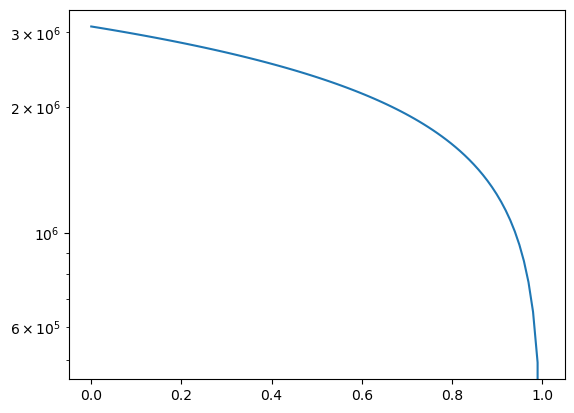

In [4]:
import matplotlib.pyplot as plt
import numpy as np

#---parameters---
L=1.e37
n0=1.0
t=1.e6*3.0*1.e7
R=42.0*(L/1.e37)**(1.0/5.0)*(n0/1.0)**(-1.0/5.0)*(t/(1.e6*3.0*1.e7))**(3.0/5.0)
#---parameters---


x = np.linspace( 0.0, 1.0,100)
T=3.1*1.e6*(L/1.e37)**(8.0/35.0)*(n0/1.0)**(2.0/35.0)*(t/(1.e6*3.0*1.e7))**(-6.0/35.0)*(1-x)**(2.0/5.0)
n=1.1*1.e-2*(L/1.e37)**(6.0/35.0)*(n0/1.0)**(19.0/35.0)*(t/(1.e6*3.0*1.e7))**(-22.0/35.0)*(1-x)**(-2.0/5.0)



plt.plot(x, T)
#plt.xscale('log')
plt.yscale('log')
plt.show()

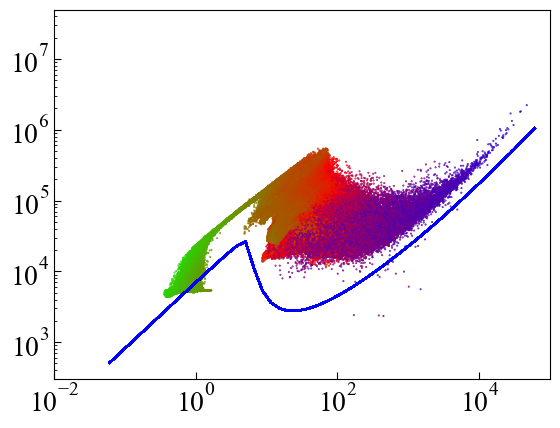

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

dir = '/Users/maedarn/Dropbox/analysis/low_metal/lmt_m2_n/'
dir1 = '/Users/maedarn/Dropbox/code/code/Cooling_Kim/'
im=128
jm=128
km=128
num=18
nstep = 20
#itime = 1
#ftime = 104
itime = 1
ftime = 117
timejump=1
#folder1="Phiwv"  #+ str(np.int(sample_frequency)) 
#older2="Phiexa"  #+ str(np.int(sample_frequency)) 

ci=51
cj=29+2#+6
cf90 = open(dir1+'Thermal_bialyi_Z10m2_md_mid.dat', 'rb')
cary = np.fromfile(cf90, np.float64, count=ci*cj)
cuvhpy = cary.reshape(cj, ci, order='F')
cT         =cuvhpy[1,:]
cndtotl =cuvhpy[12,:]

df90 = open(dir1+'Thermal_bialyi_Z10m2_md_mid.dat', 'rb')
dary = np.fromfile(df90, np.float64, count=ci*cj)
duvhpy = dary.reshape(cj, ci, order='F')
dT         =duvhpy[1,:]
dndtotl =duvhpy[12,:]

ef90 = open(dir1+'Thermal_bialyi_Z10m2_md_mid.dat', 'rb')
eary = np.fromfile(ef90, np.float64, count=ci*cj)
euvhpy = eary.reshape(cj, ci, order='F')
eT         =euvhpy[1,:]
endtotl =euvhpy[12,:]

fig = plt.figure()
plt.rcParams["font.family"] = "Times New Roman"      #全体のフォントを設定
plt.rcParams["xtick.direction"] = "in"               #x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["ytick.direction"] = "in"               #y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["xtick.major.size"] = 5                #x軸主目盛り線の長さ
plt.rcParams["ytick.major.size"] = 5                #y軸主目盛り線の長さ
plt.rcParams["font.size"] = 20   

ims = []

for i in range(itime,ftime +1,timejump):
    with h5py.File(dir+'zHDFALL'+"%03.f"%(i)+'.h5',"r")as f:
        RHO  = f["RHO/RHO"]
        Vx  = f["V/VX"]
        Vy  = f["V/VY"]
        Vz  = f["V/VZ"]
        P = f["P/P"]
        nH2 = f["RHO-h2/RHO-h2"]

        RHO_1D = np.reshape(RHO, (im*jm*km))
        P_1D = np.reshape(P, (im*jm*km))
        nH2_1D= np.reshape(nH2, (im*jm*km))
        nH2_1Df = np.log10(nH2_1D*1.27/RHO_1D)
        x1=RHO_1D/1.27
        #y1=slice5*116.0
        y1=P_1D*116.0*1.27
        
        
        plt.plot(cndtotl, cT*cndtotl*1000.0 ,color='blue',linestyle='solid')
        plt.plot(endtotl, eT*dndtotl*1000.0 ,color='blue',linestyle='dashdot')
        #kmf = plt.scatter(x1, y1, s=0.2,color='red')
        kmf = plt.scatter(x1, y1, c=nH2_1Df, vmin=-10, vmax=0, cmap='brg_r', s=0.2)
        #kmf = plt.plot(cndtotl, cT*cndtotl*1000.0 ,color='blue',linestyle='solid')
        plt.yscale('log')  # y軸をlogスケールで描く
        plt.xscale('log')  # x軸をlogスケールで描く
        #imf =  plt.pcolormesh(X,Y,xfgr2D, cmap='gnuplot_r')
        plt.xlim([0.01, 100000.0]) # x方向の描画範囲を指定
        plt.ylim([300, 50000000]) # y方向の描画範囲を指定

        #ims.append([im1]+[jm1]+[km1])
        #ims.extend([imf]+[jmf])
        ims.append([kmf])

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True,repeat_delay=100)
#ani = animation.ArtistAnimation(fig, ims, interval=50) #, blit=True,repeat_delay=100)

#ani.save('/Users/maedarn/Desktop/anim.gif', writer="imagemagick")
ani.save('/Users/maedarn/Desktop/P_n_diagram_H2_Z2.mp4', writer="ffmpeg")
plt.show()

/var/folders/kw/hmy8d3gn14j8321d_1qs3ry40000gn/T/ipykernel_14266/920286997.py:45: RuntimeWarning: invalid value encountered in scalar divide
  Vxmean = np.sum(Vxsh1) / numSH
/var/folders/kw/hmy8d3gn14j8321d_1qs3ry40000gn/T/ipykernel_14266/920286997.py:46: RuntimeWarning: invalid value encountered in scalar divide
  Vymean = np.sum(Vysh1) / numSH
/var/folders/kw/hmy8d3gn14j8321d_1qs3ry40000gn/T/ipykernel_14266/920286997.py:47: RuntimeWarning: invalid value encountered in scalar divide
  Vzmean = np.sum(Vzsh1) / numSH
/var/folders/kw/hmy8d3gn14j8321d_1qs3ry40000gn/T/ipykernel_14266/920286997.py:48: RuntimeWarning: invalid value encountered in scalar divide
  Vamean = np.sum(Va) / numSH
/var/folders/kw/hmy8d3gn14j8321d_1qs3ry40000gn/T/ipykernel_14266/920286997.py:49: RuntimeWarning: invalid value encountered in scalar divide
  Csmean = np.sum(Cs) / numSH


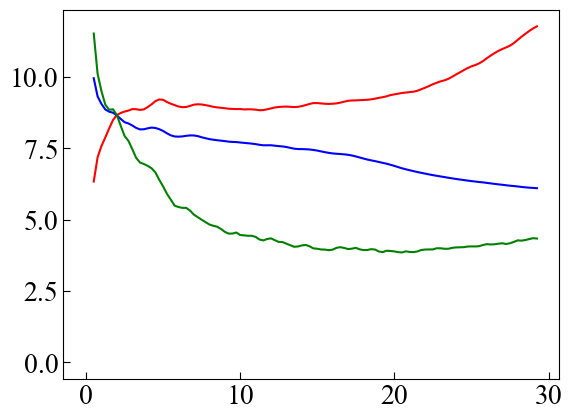

In [3]:
itime = 1
ftime = 117

Va_ls = [0] * (ftime+1)
Cs_ls = [0] * (ftime+1)
dV_ls = [0] * (ftime+1)
t_ls = [0] * (ftime+1)

for i in range(itime,ftime +1,timejump):
    with h5py.File(dir+'zHDFALL'+"%03.f"%(i)+'.h5',"r")as f:
        RHO  = f["RHO/RHO"]
        Vx  = f["V/VX"]
        Vy  = f["V/VY"]
        Vz  = f["V/VZ"]
        P = f["P/P"]
        Bx = f["B/BX"]
        By = f["B/BY"]
        Bz = f["B/BZ"] 

        RHO3D = RHO[()]
        Vx3D = Vx[()]
        Vy3D = Vy[()]
        Vz3D = Vz[()]
        Bx3D = Bx[()]
        By3D = By[()]
        Bz3D = Bz[()]
        P3D = P[()]


        Rhosh = np.where(RHO3D >= 4.0, 1, 0)
        Vxsh  = np.where(abs(Vx3D) <= 30.0, 1, 0)

        SH = Rhosh + Vxsh
        SH = np.where(SH >= 1, 1, 0)

        Vxsh1 = Vx3D * SH
        Vysh1 = Vy3D * SH
        Vzsh1 = Vz3D * SH

        Va = np.sqrt((Bx3D*Bx3D+By3D*By3D+Bz3D*Bz3D)/RHO3D) * SH
        Cs = np.sqrt(P3D/RHO3D*1.666) * SH

        numSH = np.sum(SH)

        Vxmean = np.sum(Vxsh1) / numSH
        Vymean = np.sum(Vysh1) / numSH
        Vzmean = np.sum(Vzsh1) / numSH
        Vamean = np.sum(Va) / numSH
        Csmean = np.sum(Cs) / numSH

        dVx3D = (Vx3D - Vxmean) * SH
        dVy3D = (Vy3D - Vymean) * SH
        dVz3D = (Vz3D - Vzmean) * SH

        dV = np.sqrt( np.sum((dVx3D*dVx3D+dVy3D*dVy3D+dVz3D*dVz3D)) / numSH )

        Va_ls[i] = Vamean*0.953
        Cs_ls[i] = Csmean*0.953
        dV_ls[i] = dV*0.953
        t_ls[i] = 0.25 * i
        #print(Vxmean,Vymean,Vzmean,Vamean,Csmean,dV)



plt.plot(t_ls, Va_ls, color='red')
plt.plot(t_ls, Cs_ls, color='blue')
plt.plot(t_ls, dV_ls, color='green')
plt.show()





        



In [5]:
# coding: UTF-8
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import h5py
import csv
import math
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.animation as animation
from matplotlib.animation import ArtistAnimation
from sympy import *
from sympy.codegen.cfunctions import log10

dir1='/Users/maedarn/Dropbox/analysis/low_metal/lmt_m4'

i = 130
nmesh=128.0
with h5py.File(dir1+'bG0ALL'+"%03.f"%(i)+'.h5',"r") as f:
    Rho= f["RHO/RHO"]
    nfgr = f["RHO-fgr/RHO-fgr"]
    nH2 = f["RHO-h2/RHO-h2"]
    G0 = f["G0/G0"]

    Rho3D= Rho[()]
    Rho3Dt=Rho3D.transpose(2, 1, 0)

    nH23D= nH2[()]
    nH23Dt=np.log10(nH23D.transpose(2, 1, 0))

    nfgr3D= nfgr[()]
    nfgr3Dt=nfgr3D.transpose(2, 1, 0)
    xfgr3D= np.log10(nfgr3Dt[:,:,:]*1.27/Rho3Dt[:,:,:])

    G03D= G0[()]
    G03Dt=G03D.transpose(2, 1, 0)

    #xfgr2Dn= np.log10(nfgr3Dt[64,:,:]*1.27/Rho3Dt[64,:,:] *SH)

    nfrg1D=xfgr3D.flatten()
    nH21D =nH23Dt.flatten()
    nH21Dden =np.where(nH21D > 2.0, 1.0 ,0.0)
    HDnH21D = nH21D * nH21Dden 
    HDnfrg1D = nfrg1D * nH21Dden 


print(HDnH21D)
print(np.max(nH21D),np.max(nH21Dden),np.max(HDnH21D),np.max(HDnfrg1D),np.max(nfrg1D))



fig = plt.figure()
ax = fig.add_subplot(111)
#fig.subplots_adjust(bottom=0, left=0, top=1, right=1)

#Vx_sh=Vx * shocked_Region 
#x = np.arange(1, 6)

plt.scatter(HDnH21D, HDnfrg1D, s=0.1,color='red')
ax.set_xlim([-1, 4])
ax.set_ylim([-3,  1])

pp = PdfPages('/Users/maedarn/Desktop/n_H2_xfrg.pdf')
pp.savefig(fig, bbox_inches='tight')
pp.close()



FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/Users/maedarn/Dropbox/analysis/low_metal/lmt_m4bG0ALL130.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [16]:
# coding: UTF-8
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import h5py
import csv
import math
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.animation as animation
from matplotlib.animation import ArtistAnimation
from sympy import *
from sympy.codegen.cfunctions import log10

#dir = '/Users/maedarn/Dropbox/analysis/low_metal/lmt_m4_v100_d100_old/'
dir = '/Users/maedarn/Dropbox/analysis/low_metal/lmt_m4/'
#dir1 = '/Users/maedarn/Dropbox/code/code/Cooling_Kim/'
dir1 = '/Users/maedarn/Dropbox/analysis/cooling/Kim/'
dirD = '/Users/maedarn/Desktop/'
im=128
jm=128
km=128
num=18
nstep = 20
#itime = 1
#ftime = 104
itime = 133
ftime = 133
timejump=1
#folder1="Phiwv"  #+ str(np.int(sample_frequency)) 
#older2="Phiexa"  #+ str(np.int(sample_frequency)) 

ci=51
cj=29+2+6
cf90 = open(dir1+'Thermal_bialym_Z10m4_md_mid.dat', 'rb')
#cf90 = open(dir1+'Thermal_intm2_md_mid.dat', 'rb')
cary = np.fromfile(cf90, np.float64, count=ci*cj)
cuvhpy = cary.reshape(cj, ci, order='F')
cT         =cuvhpy[1,:]
cndtotl =cuvhpy[12,:]

ci=31
cj=29
#df90 = open(dir1+'Thermal_bialym_Z10m2_md_mid.dat', 'rb')
df90 = open(dir1+'Thermal_intm2_l_mid.dat', 'rb')
dary = np.fromfile(df90, np.float64, count=ci*cj)
duvhpy = dary.reshape(cj, ci, order='F')
dT         =duvhpy[1,:]
dndtotl =duvhpy[12,:]
dG0 =duvhpy[0,:]/1.27

#ef90 = open(dir1+'Thermal_bialym_Z10m2_md_mid.dat', 'rb')
ef90 = open(dir1+'Thermal_intm2_md_mid.dat', 'rb')
eary = np.fromfile(ef90, np.float64, count=ci*cj)
euvhpy  =eary.reshape(cj, ci, order='F')
eT      =euvhpy[1,:]
endtotl =euvhpy[12,:]

#fig, ax = plt.subplots()
fig = plt.figure()
#ax = fig.add_subplot(111)
#ax1 = fig.add_subplot(111)
ax = fig.add_subplot(1,1,1)
for i in range(itime,ftime +1,timejump): #最後は含まない
#h5file1 = h5py.File(dir1+'NAllHDF'+"%03.f"%(i)+'.h5',"r")
    with h5py.File(dir+'cG0ALL'+"%03.f"%(i)+'.h5',"r")as f:
        RHO  = f["RHO/RHO"]
        P  = f["P/P"]
        nfgr = f["RHO-fgr/RHO-fgr"]
        nH2 = f["RHO-h2/RHO-h2"]
        G0 = f["G0/G0"]
        

        RHO_1D = np.reshape(RHO, (im*jm*km))
        P_1D = np.reshape(P, (im*jm*km))
        nH2_1D= np.reshape(nH2, (im*jm*km))
        nH2_1Df = np.log10(nH2_1D*1.27/RHO_1D)
        G0_1D= np.reshape(G0, (im*jm*km))
        G0_1Dlg = np.log10(G0_1D)
        x1=RHO_1D/1.27
        #y1=slice5*116.0
        y1=P_1D*116.0*1.27
        #Rho=np.reshape(RHO, im,jm,km)
    
    #mvx=np.mean(RHO)
    #shockedrho = np.where(RHO > 10.0, 1, 0)
    #shockedvx = np.where(abs(Vx) < 40.0, 1, 0)
    #shock = shockedrho + shockedvx
    #shocked_Region = np.where(shock >= 1, 1, 0)
    
    #Vx_sh=Vx * shocked_Region 
    x = np.arange(1, 6)
    #x10=10.0**x
    #y = 50*x + 1
    
    
    #ax.set_xlabel('n')  # x軸ラベル
    #ax.set_ylabel('p/k_{B}')  # y軸ラベル
    #ax.set_title(r'$\sin(x)$ and $\cos(x)$') # グラフタイトル
    # ax.set_aspect('equal') # スケールを揃える
    #ax.grid()            # 罫線
    #plt.yscale('log')
    #plt.xscale('log')
    #plt.plot(10.0**x, 50*10.0**x*0.1,color='blue')
    #matplotlib.pyplot.scatter
    plt.plot(cndtotl, cT*cndtotl*1000.0 ,color='blue',linestyle='solid')
    #plt.plot(dndtotl, dT*dndtotl*1000.0 ,color='blue',linestyle='dashed')
    #plt.plot(endtotl, eT*dndtotl*1000.0 ,color='blue',linestyle='dashdot')
    #plt.scatter(x1, y1, s=0.2,color='red')
    plt.scatter(x1, y1, c=G0_1Dlg, vmin=-5, vmax=0, cmap='viridis', s=0.2)# norm=LogNorm())#, s=20)#, c=None, marker='o', cmap=None, norm=None,vmin=None, vmax=None, alpha=None, linewidths=None,verts=None, edgecolors=None, hold=None, data=None,**kwargs)
    mappable = plt.scatter(x1, y1, c=G0_1Dlg, vmin=-5, vmax=0, cmap='viridis', s=0.2)
    fig.colorbar(mappable)
    ax.set_yscale('log')  # y軸をlogスケールで描く
    ax.set_xscale('log')  # x軸をlogスケールで描く
    ax.set_xlim([0.01, 100000]) # x方向の描画範囲を指定
    ax.set_ylim([300, 50000000])    # y方向の描画範囲を指定
    #p = plt.plot(data01,data02, "black", linestyle='dashed') # normal way
    #ax.plot(t, y1, color=c1, label=l1)
    #ax.plot(t, y2, color=c2, label=l2)
    #ax.plot(t, y3, color=c3, label=l3)
    #ax.plot(t, y4, color=c4, label=l4)
    #ax.legend(loc=0)    # 凡例
    #fig.tight_layout()  # レイアウトの設定
    plt.savefig(dirD+'hoge.png',transparent=True) # 画像の保存
    plt.show()
                    
                    
    #plt.savefig("foo.png")
    
    
   
      


FileNotFoundError: [Errno 2] No such file or directory: '/Users/maedarn/Dropbox/analysis/cooling/Kim/Thermal_bialyh_Z10m4_md_mid.dat'